# Sample Size & Power Calculator

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-science-cookbook/sample-size-calc/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-science-cookbook/sample-size-calc/demo.ipynb)

**Day 123 - Data Science Cookbook**

> "How many users do we need?" is asked at the start of every experiment and answered by vibes. Then the test runs two weeks, comes back flat, and gets recorded as "no effect" - when the honest reading is *this test never had the power to see the effect it was looking for*.

This notebook does the arithmetic that turns a guess into a plan.

## What's inside
1. **The question everyone asks** - users per arm to detect a 10% lift
2. **The question that matters more** - what your real traffic can detect in the window you actually have
3. **The cost curve** - why "let's detect a 2% lift" is not a small request
4. **Continuous metrics** - exact t-test sizing for revenue and AOV
5. **The three ways tests get silently invalidated** - multiple arms, peeking, and partial exposure
6. **Try your own numbers**

Everything runs on `numpy` + `scipy` with no data files and no API keys.

## 1. The question everyone asks

Sizing a conversion test needs four numbers:

| Input | Meaning | Who sets it |
|---|---|---|
| **Baseline rate** | what converts today | your data |
| **Effect** | the lift worth shipping for | the business |
| **Alpha** | tolerance for a false winner (0.05) | convention |
| **Power** | chance of catching a real effect (0.80) | convention |

Alpha and power are conventions worth naming out loud: at power 0.80 you are accepting a **1-in-5 chance of missing a real effect**. That is the coin flip nobody mentions in the readout.

The two-sided two-proportion formula, with pooled variance under the null:

$$n_{\text{per arm}} = \frac{\left(z_{1-\alpha/2}\sqrt{2\bar{p}(1-\bar{p})} + z_{1-\beta}\sqrt{p_1(1-p_1)+p_2(1-p_2)}\right)^2}{(p_2-p_1)^2}$$

The denominator is the whole story: **effect squared**. Halve the effect you are hunting, quadruple the users.

In [1]:
from __future__ import annotations

from typing import Dict, List, Optional

import numpy as np
import pandas as pd
from scipy import optimize, stats

import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False,
                     "axes.spines.right": False})
np.random.seed(42)

INK, BLUE, RED, AMBER, GREEN = "#1a202c", "#2b6cb0", "#c53030", "#b7791f", "#276749"


def _z(p: float) -> float:
    return float(stats.norm.ppf(p))


def n_for_proportions(baseline: float, rel_effect: float, alpha: float = 0.05,
                      power: float = 0.80) -> Dict[str, float]:
    """Users per arm for a two-sided two-proportion z-test."""
    delta = baseline * rel_effect
    treated = baseline + delta
    pooled = (baseline + treated) / 2.0
    num = (_z(1 - alpha / 2) * np.sqrt(2 * pooled * (1 - pooled))
           + _z(power) * np.sqrt(baseline * (1 - baseline)
                                 + treated * (1 - treated))) ** 2
    n = int(np.ceil(num / delta ** 2))
    return {"n_per_arm": n, "n_total": 2 * n, "treated": treated,
            "absolute_effect": delta}


def power_for_proportions(baseline: float, treated: float, n_per_arm: int,
                          alpha: float = 0.05) -> float:
    """Achieved power at a given arm size - the inverse question."""
    delta = abs(treated - baseline)
    pooled = (baseline + treated) / 2.0
    se_null = np.sqrt(2 * pooled * (1 - pooled) / n_per_arm)
    se_alt = np.sqrt((baseline * (1 - baseline)
                      + treated * (1 - treated)) / n_per_arm)
    return float(stats.norm.sf((_z(1 - alpha / 2) * se_null - delta) / se_alt))


print("Core sizing functions ready.")

Core sizing functions ready.


### The scenario

A checkout flow converting at **4.2%**. The team wants to ship a redesign and asks for a test that can detect a **10% relative lift** (4.2% -> 4.62%). The surface sees **1,800 eligible users a day** and leadership wants a call in **two weeks**.

In [2]:
BASELINE = 0.042      # current checkout conversion
TARGET_LIFT = 0.10    # 10% relative
DAILY = 1800.0        # eligible users per day
WINDOW = 14           # days leadership will wait

size = n_for_proportions(BASELINE, TARGET_LIFT)
days = size["n_total"] / DAILY

print(f"Baseline           {BASELINE*100:.2f}%")
print(f"Target             {size['treated']*100:.2f}%  "
      f"(+{size['absolute_effect']*100:.2f}pp, +{TARGET_LIFT*100:.0f}% relative)")
print("-" * 52)
print(f"Users per arm      {size['n_per_arm']:>10,}")
print(f"Users total        {size['n_total']:>10,}")
print(f"Days at {DAILY:,.0f}/day   {days:>10.1f}")
print("-" * 52)
print(f"Window available   {WINDOW:>10} days")
print(f"Verdict            {'FEASIBLE' if days <= WINDOW else 'NOT FEASIBLE':>10}")

# sanity: the sizing round-trips through the power function
check = power_for_proportions(BASELINE, size["treated"], size["n_per_arm"])
print(f"\nPower check at that n: {check:.3f}  (asked for 0.800)")

Baseline           4.20%
Target             4.62%  (+0.42pp, +10% relative)
----------------------------------------------------
Users per arm          37,513
Users total            75,026
Days at 1,800/day         41.7
----------------------------------------------------
Window available           14 days
Verdict            NOT FEASIBLE

Power check at that n: 0.800  (asked for 0.800)


**42 days, not 14.**

This is the moment the plan usually gets quietly abandoned instead of fixed. The test runs for its two weeks anyway, comes back p = 0.31, and the redesign is shelved on evidence that was never there.

Note the sanity check: feeding that sample size back into an independently-derived power function returns 0.800. The two formulas are inverses, so if they agree the arithmetic is sound.

## 2. The question that matters more

Sample size is the wrong direction to solve in. You do not get to choose your traffic - it chooses you. So invert it: **given 14 days at 1,800 users a day, what is the smallest lift I could detect?**

That is the *minimum detectable effect* (MDE), and it is the number that should be on the pre-test doc. Solved here by bisection on the sizing function so the answer is guaranteed consistent with the arithmetic above.

In [3]:
def mde_for_proportions(baseline: float, n_per_arm: int, alpha: float = 0.05,
                        power: float = 0.80) -> Optional[float]:
    """Smallest relative lift detectable at this arm size. None if unreachable."""
    def shortfall(rel: float) -> float:
        return n_for_proportions(baseline, rel, alpha, power)["n_per_arm"] - n_per_arm

    lo, hi = 1e-5, 0.01
    while shortfall(hi) > 0:
        hi *= 2.0
        if baseline * (1 + hi) >= 1.0 or hi > 50.0:
            return None                      # no lift is detectable at this n
    return float(optimize.brentq(shortfall, lo, hi, xtol=1e-6))


budget_per_arm = int(DAILY * WINDOW // 2)
mde = mde_for_proportions(BASELINE, budget_per_arm)

print(f"In {WINDOW} days you collect {int(DAILY*WINDOW):,} users "
      f"= {budget_per_arm:,} per arm.\n")
print(f"Smallest detectable lift:  {mde*100:.1f}% relative "
      f"({BASELINE*mde*100:.2f}pp)")
print(f"Which means:               {BASELINE*100:.2f}% -> "
      f"{BASELINE*(1+mde)*100:.2f}%")
print(f"\nYou asked to detect:       {TARGET_LIFT*100:.1f}%")
print(f"You can actually detect:   {mde*100:.1f}%  "
      f"({mde/TARGET_LIFT:.1f}x larger)")

# what power the original 10% test would have actually had
actual = power_for_proportions(BASELINE, BASELINE*(1+TARGET_LIFT), budget_per_arm)
print(f"\nIf you ran the 14-day test anyway, its power to see a 10% lift "
      f"would be {actual:.2f}.")
print(f"That is a {(1-actual)*100:.0f}% chance of missing a real 10% win "
      f"and calling the redesign a failure.")

In 14 days you collect 25,200 users = 12,600 per arm.

Smallest detectable lift:  17.5% relative (0.74pp)
Which means:               4.20% -> 4.94%

You asked to detect:       10.0%
You can actually detect:   17.5%  (1.8x larger)

If you ran the 14-day test anyway, its power to see a 10% lift would be 0.37.
That is a 63% chance of missing a real 10% win and calling the redesign a failure.


That last line is the whole point of doing this before the test instead of after.

The 14-day test is not neutral. It is weighted *against* your redesign - a real 10% win has better-than-even odds of being recorded as a failure. If it comes back flat you will have learned nothing except that you did not collect enough data.

## 3. The cost curve

Effect appears **squared** in the denominator, so the relationship between ambition and cost is brutally non-linear. Here is what each lift target costs on this surface.

In [4]:
lifts = [0.02, 0.05, 0.075, 0.10, 0.15, 0.20, 0.30, 0.50]
rows = []
for rel in lifts:
    s = n_for_proportions(BASELINE, rel)
    rows.append({"Relative lift": f"{rel*100:.1f}%",
                 "Treated rate": f"{s['treated']*100:.2f}%",
                 "Users / arm": f"{s['n_per_arm']:,}",
                 "Total users": f"{s['n_total']:,}",
                 "Days": round(s["n_total"] / DAILY, 1),
                 "Fits 14d": "yes" if s["n_total"]/DAILY <= WINDOW else "no"})

table = pd.DataFrame(rows)
print(f"Baseline {BASELINE*100:.1f}%, {DAILY:,.0f} users/day, "
      f"alpha 0.05, power 0.80\n")
print(table.to_string(index=False))

Baseline 4.2%, 1,800 users/day, alpha 0.05, power 0.80

Relative lift Treated rate Users / arm Total users   Days Fits 14d
         2.0%        4.28%     903,700   1,807,400 1004.1       no
         5.0%        4.41%     146,642     293,284  162.9       no
         7.5%        4.52%      65,933     131,866   73.3       no
        10.0%        4.62%      37,513      75,026   41.7       no
        15.0%        4.83%      17,050      34,100   18.9       no
        20.0%        5.04%       9,803      19,606   10.9      yes
        30.0%        5.46%       4,544       9,088    5.0      yes
        50.0%        6.30%       1,770       3,540    2.0      yes


Detecting a 2% lift takes **1,004 days**. Nearly three years - on a surface that will be redesigned four times before then.

This table is the answer to "can't we just be a bit more sensitive?" No: sensitivity is quadratic, and at some point the honest move is to test a bigger change rather than to measure a small one more precisely.

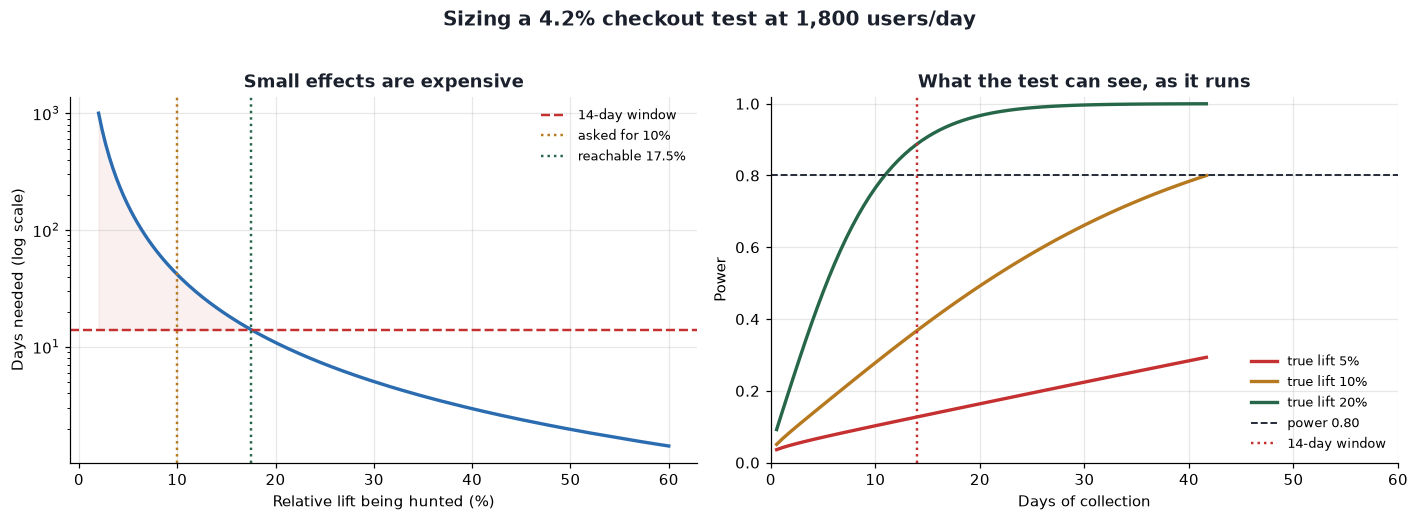

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))

# --- left: days vs lift, log scale, with the window as a hard line
rel_grid = np.linspace(0.02, 0.60, 160)
days_grid = [n_for_proportions(BASELINE, r)["n_total"] / DAILY for r in rel_grid]

ax1.plot(rel_grid * 100, days_grid, color=BLUE, lw=2.2)
ax1.axhline(WINDOW, color=RED, ls="--", lw=1.6, label=f"{WINDOW}-day window")
ax1.axvline(TARGET_LIFT * 100, color=AMBER, ls=":", lw=1.6,
            label=f"asked for {TARGET_LIFT*100:.0f}%")
ax1.axvline(mde * 100, color=GREEN, ls=":", lw=1.6,
            label=f"reachable {mde*100:.1f}%")
ax1.fill_between(rel_grid * 100, WINDOW, days_grid,
                 where=np.array(days_grid) > WINDOW, color=RED, alpha=0.07)
ax1.set_yscale("log")
ax1.set_xlabel("Relative lift being hunted (%)")
ax1.set_ylabel("Days needed (log scale)")
ax1.set_title("Small effects are expensive", color=INK, fontweight="bold")
ax1.legend(fontsize=8.5, frameon=False)

# --- right: power as the test runs, for three candidate true effects
n_grid = np.arange(500, budget_per_arm * 3, 500)
for rel, c, ls in [(0.05, RED, "-"), (0.10, AMBER, "-"), (0.20, GREEN, "-")]:
    p = [power_for_proportions(BASELINE, BASELINE*(1+rel), int(n)) for n in n_grid]
    ax2.plot(n_grid * 2 / DAILY, p, color=c, ls=ls, lw=2.2,
             label=f"true lift {rel*100:.0f}%")
ax2.axhline(0.80, color=INK, ls="--", lw=1.2, label="power 0.80")
ax2.axvline(WINDOW, color=RED, ls=":", lw=1.6, label=f"{WINDOW}-day window")
ax2.set_xlim(0, 60)
ax2.set_ylim(0, 1.02)
ax2.set_xlabel("Days of collection")
ax2.set_ylabel("Power")
ax2.set_title("What the test can see, as it runs", color=INK, fontweight="bold")
ax2.legend(fontsize=8.5, frameon=False, loc="lower right")

fig.suptitle("Sizing a 4.2% checkout test at 1,800 users/day",
             fontsize=13, fontweight="bold", color=INK, y=1.02)
fig.tight_layout()
fig.savefig("sample_size_calc.png", dpi=150, bbox_inches="tight")
plt.show()

The right panel is the one to put in front of a stakeholder. At the 14-day line, a true 20% lift is nearly certain to be caught, a 10% lift is caught barely a third of the time, and a 5% lift is invisible.

**Same test, three completely different reliabilities** - depending on a true effect size you do not know in advance. That is why you size for the smallest lift *worth shipping*, not the one you hope for.

## 4. Continuous metrics need different math

Revenue per user, average order value, session length: no conversion rate, so the input is the metric's **standard deviation**, and the effect size that matters is the ratio $d = \delta/\sigma$ (Cohen's d).

The normal-approximation formula understates n at small samples, so this solves the exact two-sample t-test power using the **noncentral t** distribution.

In [6]:
def n_for_means(sigma: float, delta: float, alpha: float = 0.05,
                power: float = 0.80) -> Dict[str, float]:
    """Exact two-sample t-test sizing via the noncentral t distribution."""
    d = delta / sigma

    def achieved(n: float) -> float:
        n = max(2.0, n)
        df, ncp = 2 * n - 2, d * np.sqrt(n / 2)
        crit = stats.t.ppf(1 - alpha / 2, df)
        return float(stats.nct.sf(crit, df, ncp) + stats.nct.cdf(-crit, df, ncp))

    n = 2.0
    while achieved(n) < power and n < 5e7:
        n *= 1.5
    lo, hi = max(2.0, n / 1.5), n
    for _ in range(60):                       # bisect to the exact crossing
        mid = (lo + hi) / 2
        lo, hi = (mid, hi) if achieved(mid) < power else (lo, mid)
    n_per_arm = int(np.ceil(hi))
    return {"n_per_arm": n_per_arm, "d": d, "achieved_power": achieved(n_per_arm)}


# AOV of $86 with a std dev of $42 - typical heavy-tailed ecommerce spread
AOV_SIGMA = 42.0
scenarios = [("+$1.00", 1.0), ("+$3.00", 3.0), ("+$5.00", 5.0), ("+$10.00", 10.0)]

print(f"AOV std dev = ${AOV_SIGMA:.0f}, alpha 0.05, power 0.80\n")
print(f"{'Shift':>8}  {'Cohen d':>8}  {'Users/arm':>11}  {'Days':>7}  {'Power':>6}")
print("-" * 48)
for label, delta in scenarios:
    r = n_for_means(AOV_SIGMA, delta)
    d_days = r["n_per_arm"] * 2 / DAILY
    print(f"{label:>8}  {r['d']:>8.3f}  {r['n_per_arm']:>11,}  "
          f"{d_days:>7.1f}  {r['achieved_power']:>6.3f}")

print("\nNote how a $1 shift on a $42 std dev is d=0.024 - a genuinely tiny")
print("effect, and priced accordingly. Variance, not the dollar amount, sets the bill.")

AOV std dev = $42, alpha 0.05, power 0.80

   Shift   Cohen d    Users/arm     Days   Power
------------------------------------------------
  +$1.00     0.024       27,692     30.8   0.800
  +$3.00     0.071        3,078      3.4   0.800
  +$5.00     0.119        1,109      1.2   0.800
 +$10.00     0.238          278      0.3   0.800

Note how a $1 shift on a $42 std dev is d=0.024 - a genuinely tiny
effect, and priced accordingly. Variance, not the dollar amount, sets the bill.


A useful reflex from this table: before asking "is this shift detectable?", ask **"how noisy is the metric?"** A $1 AOV move sounds concrete and is statistically almost invisible, because the spread between customers dwarfs it.

Revenue metrics are also heavy-tailed - a handful of whales can dominate the variance. Winsorising the top 1% or testing a bounded proxy (conversion, items-per-order) often buys more power than collecting more users.

## 5. Three ways a correctly-sized test still gets invalidated

The sample size can be right and the conclusion still wrong. These three are the common ones, and all three are decided *before* the test starts.

In [7]:
# --- (a) multiple arms inflate the false-positive rate
print("(a) MULTIPLE ARMS - alpha is per comparison, not per test\n")
print(f"{'Arms':>5}  {'Comparisons':>12}  {'P(>=1 false winner)':>21}  {'Bonferroni a':>13}")
print("-" * 58)
for arms in [2, 3, 4, 5, 8]:
    comps = arms - 1
    fw = 1 - (1 - 0.05) ** comps
    print(f"{arms:>5}  {comps:>12}  {fw*100:>20.1f}%  {0.05/comps:>13.4f}")
print("\n    An innocent 4-arm test carries a 14.3% chance of a false winner")
print("    while everyone in the room believes it is 5%.\n")

# --- (b) peeking: simulate an A/A test stopped at the first significant look
print("(b) PEEKING - simulated A/A tests (no real effect at all)\n")


def aa_trial(n_max: int, looks: int, alpha: float = 0.05) -> bool:
    """True if an A/A test hits significance at ANY of `looks` checkpoints."""
    a = np.random.binomial(1, BASELINE, n_max)
    b = np.random.binomial(1, BASELINE, n_max)
    for n in np.linspace(n_max / looks, n_max, looks).astype(int):
        ca, cb = a[:n].sum(), b[:n].sum()
        p_pool = (ca + cb) / (2 * n)
        se = np.sqrt(2 * p_pool * (1 - p_pool) / n) if 0 < p_pool < 1 else 0.0
        if se > 0 and abs(cb - ca) / n / se > _z(1 - alpha / 2):
            return True
    return False


TRIALS = 2000
for looks in [1, 2, 7, 14]:
    rate = np.mean([aa_trial(4000, looks) for _ in range(TRIALS)])
    label = "once at the end" if looks == 1 else f"{looks} times"
    print(f"    Look {label:<16}  false positive rate: {rate*100:>5.1f}%")
print("\n    Two identical variants, no effect at all. The only thing that")
print("    changed is how often you looked.\n")

# --- (c) partial exposure stretches the calendar
print("(c) PARTIAL EXPOSURE - a 25% ramp is a 4x longer test\n")
for share in [1.0, 0.5, 0.25, 0.10]:
    d = size["n_total"] / (DAILY * share)
    print(f"    {share*100:>3.0f}% of traffic exposed -> {d:>7.1f} days")

(a) MULTIPLE ARMS - alpha is per comparison, not per test

 Arms   Comparisons    P(>=1 false winner)   Bonferroni a
----------------------------------------------------------
    2             1                   5.0%         0.0500
    3             2                   9.8%         0.0250
    4             3                  14.3%         0.0167
    5             4                  18.5%         0.0125
    8             7                  30.2%         0.0071

    An innocent 4-arm test carries a 14.3% chance of a false winner
    while everyone in the room believes it is 5%.

(b) PEEKING - simulated A/A tests (no real effect at all)

    Look once at the end   false positive rate:   4.2%
    Look 2 times           false positive rate:   7.9%
    Look 7 times           false positive rate:  15.6%
    Look 14 times          false positive rate:  22.6%

    Two identical variants, no effect at all. The only thing that
    changed is how often you looked.

(c) PARTIAL EXPOSURE - a 25% r

The peeking simulation is worth sitting with: **two identical variants, no effect whatsoever**, and checking daily for two weeks produces a "significant" result about 23% of the time instead of 5% - roughly five times the false-positive rate you think you are running. Nothing about the data changed, only the stopping rule.

If you need to look early, use a method built for it (sequential testing, alpha spending). Do not look at a fixed-horizon test and stop when it looks good.

## Summary

| Question | Answer for this test |
|---|---|
| Users per arm for a 10% lift | **37,513** |
| Days at 1,800/day | **42** |
| Days available | **14** |
| Detectable in 14 days | **17.5% lift** |
| Power of the 14-day test to see a 10% lift | **0.37** |

The pre-test doc should say: *"With 14 days of traffic we can detect a 17.5% lift at 80% power. If the redesign moves conversion less than that, this test will report flat regardless of whether it worked."*

That sentence protects the redesign, the analyst, and the decision - and it costs one function call to write.

## 6. Try your own numbers

Swap in your baseline, your traffic, and the lift your team is arguing about.

In [8]:
# ---- your test -----------------------------------------------------------
MY_BASELINE = 0.042     # current rate, e.g. 0.042 for 4.2%
MY_LIFT     = 0.10      # relative lift worth shipping for
MY_DAILY    = 1800.0    # eligible users per day
MY_WINDOW   = 14        # days you actually have
MY_ARMS     = 2         # arms including control
MY_EXPOSURE = 1.0       # share of traffic in the test
# --------------------------------------------------------------------------

s = n_for_proportions(MY_BASELINE, MY_LIFT)
total = s["n_per_arm"] * MY_ARMS
d = total / (MY_DAILY * MY_EXPOSURE)
per_arm_budget = int(MY_DAILY * MY_EXPOSURE * MY_WINDOW // MY_ARMS)
reach = mde_for_proportions(MY_BASELINE, per_arm_budget)

print(f"To detect a {MY_LIFT*100:.0f}% lift on {MY_BASELINE*100:.2f}%:")
print(f"  {s['n_per_arm']:,} per arm, {total:,} total, {d:.1f} days\n")
if reach is None:
    print(f"In {MY_WINDOW} days you cannot detect any lift at this traffic.")
else:
    print(f"In {MY_WINDOW} days you can detect: {reach*100:.1f}% relative "
          f"({MY_BASELINE*reach*100:.2f}pp)")
    got = power_for_proportions(MY_BASELINE, MY_BASELINE*(1+MY_LIFT),
                                per_arm_budget)
    print(f"Power of the {MY_WINDOW}-day test to see your {MY_LIFT*100:.0f}% "
          f"lift: {got:.2f}")
    verdict = "GO" if d <= MY_WINDOW else "RESCOPE - underpowered as planned"
    print(f"\nVerdict: {verdict}")

if MY_ARMS > 2:
    fw = 1 - (1 - 0.05) ** (MY_ARMS - 1)
    print(f"\n{MY_ARMS} arms: {fw*100:.1f}% family-wise error uncorrected. "
          f"Use alpha = {0.05/(MY_ARMS-1):.4f} per comparison.")

To detect a 10% lift on 4.20%:
  37,513 per arm, 75,026 total, 41.7 days

In 14 days you can detect: 17.5% relative (0.74pp)
Power of the 14-day test to see your 10% lift: 0.37

Verdict: RESCOPE - underpowered as planned


---

## The Streamlit version

The full app adds absolute-vs-relative effect entry, alpha/power sliders, Bonferroni and Sidak corrections, continuous-metric mode, traffic ramping, and a downloadable plan CSV:

```bash
pip install -r requirements.txt
streamlit run app.py
```

The UI-free math lives in `power.py` - import it into a pipeline or a pre-test doc generator.

## Related builds

- **[stat-test-advisor](../stat-test-advisor/)** (Day 111) - which test to run once the data is in
- **[threshold-explorer](../../ml-engineering-toolkit/threshold-explorer/)** (Day 122) - picking a decision cutoff on purpose
- **[ab-test-calc](../../analytics-accelerator/ab-test-calc/)** (Day 23) - significance after the test

Part of **[phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder)** - a daily 30-minute build habit.